In [179]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Basic Data Information

##### Height_cm — Height of the individual in centimeters
##### Weight_kg — Weight of the individual in kilograms
##### Gender — Gender of the individual (Male / Female)
##### Age — Age in years
##### BMI — Body Mass Index calculated from height and weight
##### Weight_Category — BMI-based category (Underweight, Normal, Overweight, Obese)
##### Systolic_BP — Systolic blood pressure reading
##### Diastolic_BP — Diastolic blood pressure reading
##### Cholesterol_Level — Cholesterol level indicator
##### Physical_Activity_Level — Level of physical activity
##### Smoking_Status — Smoking habit indicator
##### Health_Risk_Score — Derived health risk metric
##### Activity_Index — Numeric representation of lifestyle activity

In [180]:
df = pd.read_csv(r"C:\Users\Ayobami Adeyemo\Downloads\archive (15)\weight-height.csv")
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


## EDA

In [181]:
df.shape

(50000, 13)

In [182]:
df.describe()

,Height,Weight,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,168.791384,67.349698,49.068700,23.504342,120.220500,80.11208,202.175240
std,9.886864,11.206605,18.213465,2.279060,14.726255,9.83213,36.331602
min,145.000000,45.000000,18.000000,15.830000,90.000000,60.00000,150.000000
25%,161.540000,59.080000,33.000000,21.940000,110.000000,73.00000,173.000000
50%,168.450000,66.570000,49.000000,23.440000,120.000000,80.00000,200.000000
75%,175.730000,75.020000,65.000000,25.000000,130.000000,87.00000,227.000000
max,200.000000,111.330000,80.000000,34.460000,176.000000,120.00000,300.000000


In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Height                50000 non-null  float64
 1   Weight                50000 non-null  float64
 2   Gender                50000 non-null  str    
 3   Age                   50000 non-null  int64  
 4   BMI                   50000 non-null  float64
 5   Weight_Category       50000 non-null  str    
 6   Activity_Level        50000 non-null  str    
 7   Systolic_BP           50000 non-null  int64  
 8   Diastolic_BP          50000 non-null  int64  
 9   BP_Category           50000 non-null  str    
 10  Cholesterol           50000 non-null  int64  
 11  Cholesterol_Category  50000 non-null  str    
 12  Smoker                50000 non-null  str    
dtypes: float64(3), int64(4), str(6)
memory usage: 5.0 MB


In [184]:
df.isnull().sum()

Height                  0
Weight                  0
Gender                  0
Age                     0
BMI                     0
Weight_Category         0
Activity_Level          0
Systolic_BP             0
Diastolic_BP            0
BP_Category             0
Cholesterol             0
Cholesterol_Category    0
Smoker                  0
dtype: int64

In [185]:
df[['Age', 'Height']].corr()

,Age,Height
Age,1.000000,-0.004422
Height,-0.004422,1.000000


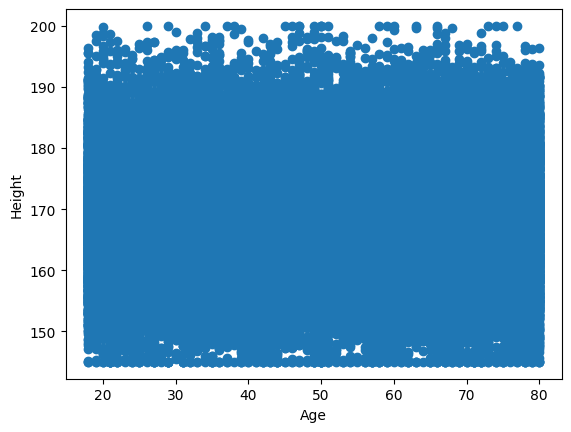

In [186]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Height'])
plt.xlabel("Age")
plt.ylabel("Height")
plt.show()

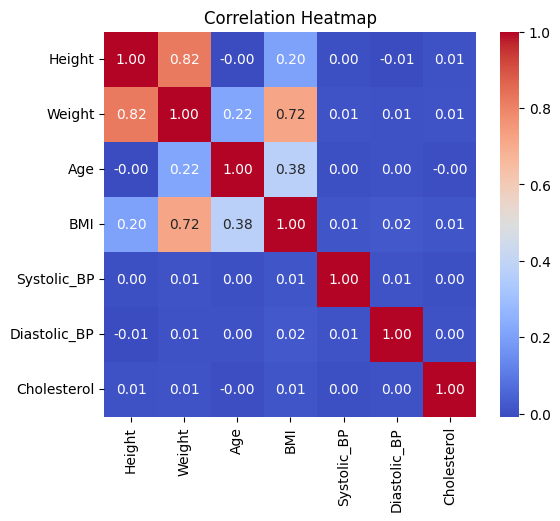

In [187]:
numeric_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

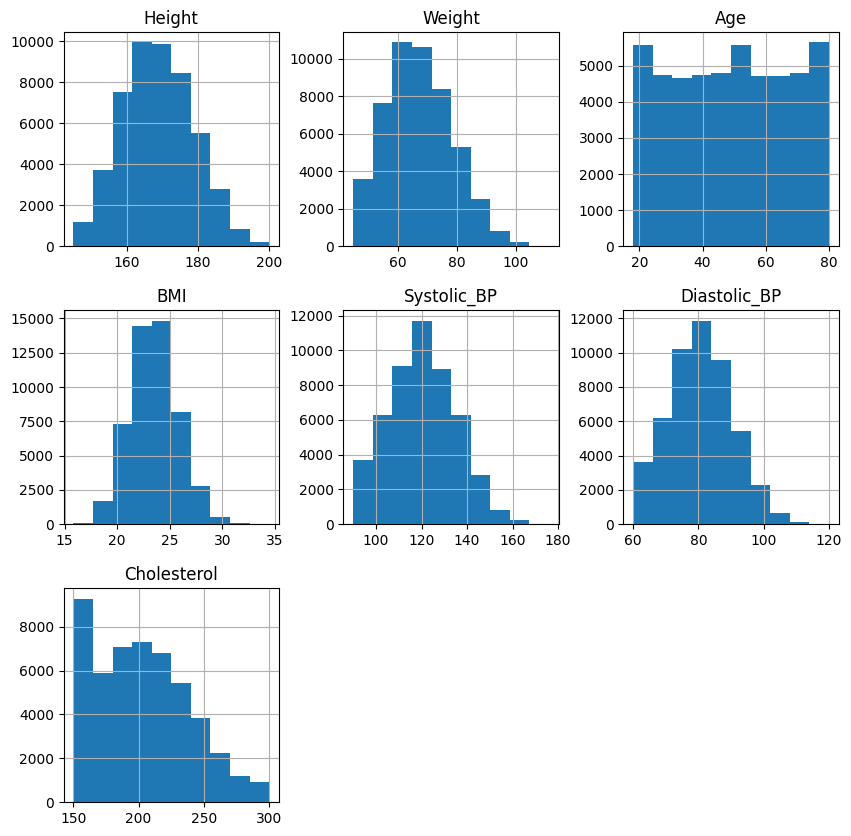

In [188]:
histplot = df.hist(column = ['Height', 'Weight', 'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol'], figsize=(10,10))



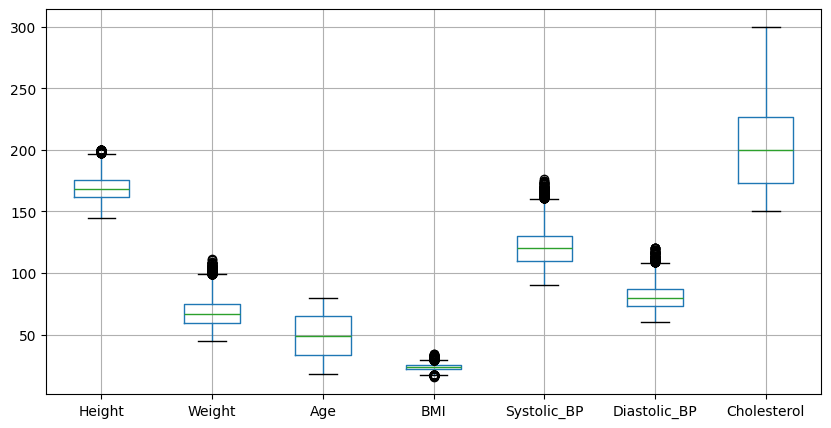

In [189]:
plt.subplots(figsize=(10,5))
boxplot = df.boxplot(column = ['Height', 'Weight', 'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol'])
plt.show(boxplot)

In [190]:
#sns.pairplot(df, hue="Height")
#plt.show()

In [191]:
df.groupby('Weight_Category')['Height'].count()

Weight_Category
Normal         36993
Obese            175
Overweight     12383
Underweight      449
Name: Height, dtype: int64

In [192]:
weight_category_map = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3
}

df['Weight_Category'] = df['Weight_Category'].map(weight_category_map)

In [193]:
df.Activity_Level.value_counts()

Activity_Level
Lightly Active       17596
Sedentary            16955
Moderately Active    11621
Very Active           3828
Name: count, dtype: int64

In [194]:
activity_level_map = {
    'Lightly Active': 0,
    'Sedentary': 1,
    'Moderately Active': 2,
    'Very Active': 3}
df['Activity_Level'] = df['Activity_Level'].map(activity_level_map)



In [195]:
df.BP_Category.value_counts()

BP_Category
Elevated    25575
High        12687
Normal      11738
Name: count, dtype: int64

In [196]:
bp_category_map = {
    'Normal': 0,
    'High': 1,
    'Elevated': 2
}

df['BP_Category'] = df['BP_Category'].map(bp_category_map)

In [197]:
df.Cholesterol_Category.value_counts()

Cholesterol_Category
Normal        24724
Borderline    17041
High           8235
Name: count, dtype: int64

In [198]:
cholesterol_map = {
    'Normal': 0,
    'Borderline': 1,
    'High': 2
}

df['Cholesterol_Category'] = df['Cholesterol_Category'].map(cholesterol_map)

In [199]:
df.Smoker.value_counts()

Smoker
No     43640
Yes     6360
Name: count, dtype: int64

In [200]:
smoker_map = {
    'Yes': 1,
    'No': 0
}
df['Smoker'] = df['Smoker'].map(smoker_map)

In [201]:
BMI_Map = [
    df['BMI'] < 18.5,
    (df['BMI'] >= 18.5) & (df['BMI'] < 25),
    (df['BMI'] >= 25) & (df['BMI'] < 30),
    df['BMI'] >= 30
]

categories = ['Underweight', 'Normal', 'Overweight', 'Obesity']

df['BMI_Category'] = np.select(
    BMI_Map,
    categories,
    default='Unknown'
)


In [202]:
df.Weight_Category.value_counts()

Weight_Category
1    36993
2    12383
0      449
3      175
Name: count, dtype: int64

In [203]:
display(df.groupby('Weight_Category')['BMI'].value_counts())

Weight_Category  BMI  
0                18.46    13
                 18.35    11
                 18.32     9
                 17.99     8
                 18.31     8
                          ..
3                31.68     1
                 30.54     1
                 30.23     1
                 32.17     1
                 32.19     1
Name: count, Length: 1416, dtype: int64

In [204]:
df['Weight_Category'].describe()

count    50000.000000
mean         1.245680
std          0.458569
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Weight_Category, dtype: float64

In [205]:
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker,BMI_Category
0,161.72,53.80,Female,19,20.57,1,1,140,90,1,150,0,0,Normal
1,171.99,76.12,Male,56,25.73,2,0,122,73,2,192,0,0,Overweight
2,179.51,87.38,Male,69,27.12,2,1,126,97,1,231,1,0,Overweight
3,179.68,74.28,Male,20,23.01,1,3,102,71,0,235,1,0,Normal
4,162.94,62.76,Female,54,23.64,1,0,126,60,2,249,2,0,Normal


In [206]:
df_dummy = pd.get_dummies(df, columns=['Gender', 'Smoker'], dtype=int)
df_dummy.head()

,Height,Weight,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,BMI_Category,Gender_Female,Gender_Male,Smoker_0,Smoker_1
0,161.72,53.80,19,20.57,1,1,140,90,1,150,0,Normal,1,0,1,0
1,171.99,76.12,56,25.73,2,0,122,73,2,192,0,Overweight,0,1,1,0
2,179.51,87.38,69,27.12,2,1,126,97,1,231,1,Overweight,0,1,1,0
3,179.68,74.28,20,23.01,1,3,102,71,0,235,1,Normal,0,1,1,0
4,162.94,62.76,54,23.64,1,0,126,60,2,249,2,Normal,1,0,1,0


In [207]:
df_dummy.isnull().sum()

Height                  0
Weight                  0
Age                     0
BMI                     0
Weight_Category         0
Activity_Level          0
Systolic_BP             0
Diastolic_BP            0
BP_Category             0
Cholesterol             0
Cholesterol_Category    0
BMI_Category            0
Gender_Female           0
Gender_Male             0
Smoker_0                0
Smoker_1                0
dtype: int64

In [208]:
df_dummy.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Height                50000 non-null  float64
 1   Weight                50000 non-null  float64
 2   Age                   50000 non-null  int64  
 3   BMI                   50000 non-null  float64
 4   Weight_Category       50000 non-null  int64  
 5   Activity_Level        50000 non-null  int64  
 6   Systolic_BP           50000 non-null  int64  
 7   Diastolic_BP          50000 non-null  int64  
 8   BP_Category           50000 non-null  int64  
 9   Cholesterol           50000 non-null  int64  
 10  Cholesterol_Category  50000 non-null  int64  
 11  BMI_Category          50000 non-null  str    
 12  Gender_Female         50000 non-null  int64  
 13  Gender_Male           50000 non-null  int64  
 14  Smoker_0              50000 non-null  int64  
 15  Smoker_1              50000 no

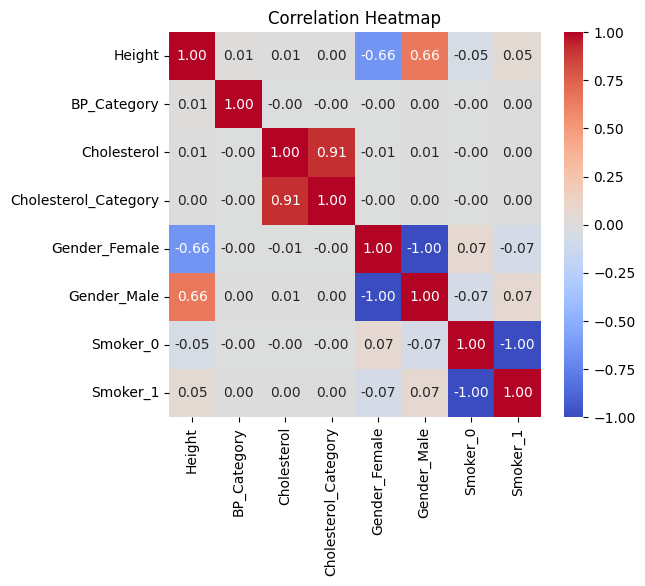

In [209]:
df_dummy_1 = df_dummy.drop(columns=['Weight', 'Age', 'BMI', 'Weight_Category', 'Activity_Level', 'Systolic_BP', 'Diastolic_BP'])

numeric_df_1 = df_dummy_1.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df_1.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

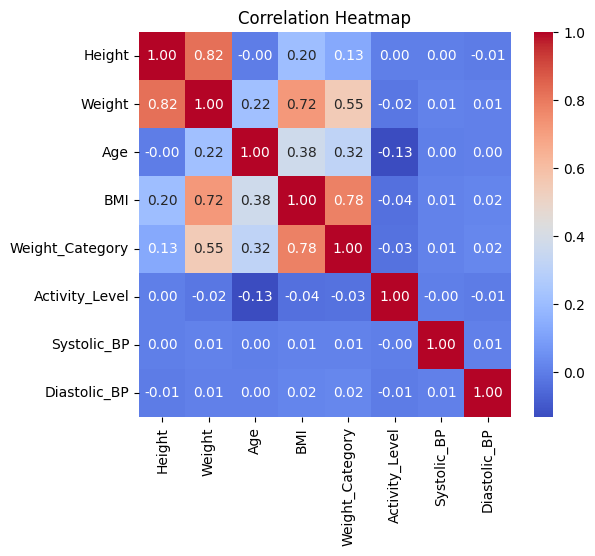

In [210]:
df_dummy_2 = df_dummy.drop(columns=['BP_Category', 'Cholesterol' , 'Cholesterol_Category', 'Gender_Female', 'Gender_Male', 'Smoker_0', 'Smoker_1'])

numeric_df_2 = df_dummy_2.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df_2.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [211]:
df_dummy.head()

,Height,Weight,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,BMI_Category,Gender_Female,Gender_Male,Smoker_0,Smoker_1
0,161.72,53.80,19,20.57,1,1,140,90,1,150,0,Normal,1,0,1,0
1,171.99,76.12,56,25.73,2,0,122,73,2,192,0,Overweight,0,1,1,0
2,179.51,87.38,69,27.12,2,1,126,97,1,231,1,Overweight,0,1,1,0
3,179.68,74.28,20,23.01,1,3,102,71,0,235,1,Normal,0,1,1,0
4,162.94,62.76,54,23.64,1,0,126,60,2,249,2,Normal,1,0,1,0


In [212]:
df_dummy = df_dummy.drop(columns=['Age', 'Activity_Level', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol', 'Cholesterol_Category', 'BP_Category'])

In [218]:
df_dummy.head()

,Height,Weight,BMI,Weight_Category,BMI_Category,Gender_Female,Gender_Male,Smoker_0,Smoker_1
0,161.72,53.80,20.57,1,Normal,1,0,1,0
1,171.99,76.12,25.73,2,Overweight,0,1,1,0
2,179.51,87.38,27.12,2,Overweight,0,1,1,0
3,179.68,74.28,23.01,1,Normal,0,1,1,0
4,162.94,62.76,23.64,1,Normal,1,0,1,0


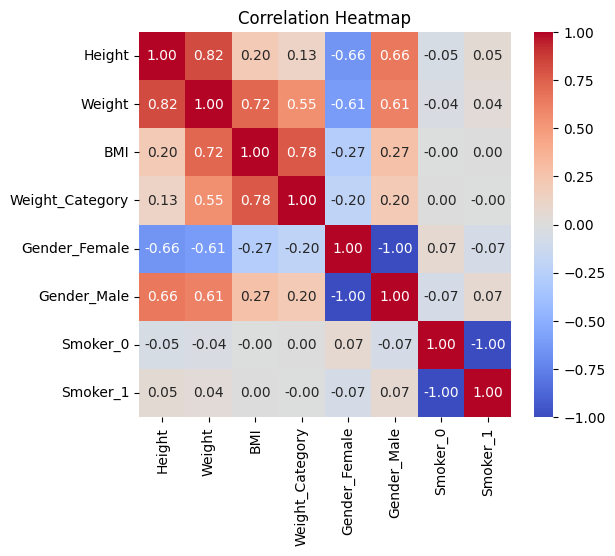

In [214]:
numeric_df = df_dummy.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [215]:
X = df_dummy.drop(columns=['Height'])
y = df_dummy['Height']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40000, 8) (10000, 8) (40000,) (10000,)


In [216]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Overweight'

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9997424943033172
MAE: 0.05676800793730074
MSE: 0.025097089879036655


In [ ]:
print(f"Training Accuracy: {model.score(X_train, y_train)}")
print(f"Testing Accuracy: {model.score(X_test, y_test)}")

Training Accuracy: 0.999972970833922
Testing Accuracy: 0.9997424943033172


In [ ]:
y_pred = model.predict(X_test)

results = X_test.copy()

results["Actual Height"] = y_test
results["Predicted Height"] = y_pred

#print(results.head(5))
results.head(5)

,Weight,BMI,BMI_Category,Gender_Female,Gender_Male,Smoker_0,Smoker_1,Actual Height,Predicted Height
33553,67.17,21.76,NaN,0,1,1,0,175.69,175.6094
9427,83.90,25.54,NaN,0,1,1,0,181.25,181.2456
199,65.46,20.36,NaN,1,0,1,0,179.29,179.1162
12447,59.56,19.57,NaN,0,1,1,0,174.47,174.3408
39489,81.66,26.00,NaN,0,1,1,0,177.21,177.1908


In [ ]:
new_data_1 = pd.DataFrame({
    'Weight': [68],
    'BMI': [22.5],
    'Gender': [1],
    'Smoker': [1],

})

In [ ]:
new_data_encoded_1 = pd.get_dummies(new_data_1, drop_first=True)
new_data_encoded_1 = new_data_encoded_1.reindex(columns=X.columns, fill_value=0)
prediction_1 = model.predict(new_data_encoded_1)
print(f"Predicted Height: {prediction_1[0]:.2f}")

Predicted Height: 173.80


### Category [1, 2, 3]
BMI Range
UnderweightBelow 18.5
Healthy Weight18.5 – 24.9
Overweight25.0 – 29.9
Obesity30.0 or higher

BMI is weight in kilograms (kg) divided by height in meters (m) squared

just some information